Saving data.csv to data.csv


/tmp/ipykernel_15299/3008823888.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(next(iter(uploaded)), encoding='latin1')


Epoch 0 | D Loss: 1.2223 | G Loss: 0.6454
Epoch 50 | D Loss: 1.1768 | G Loss: 0.7009
Epoch 100 | D Loss: 1.1873 | G Loss: 0.8407
Epoch 150 | D Loss: 1.0228 | G Loss: 1.0397
Epoch 200 | D Loss: 1.0516 | G Loss: 0.8268
Epoch 250 | D Loss: 1.1317 | G Loss: 0.8299


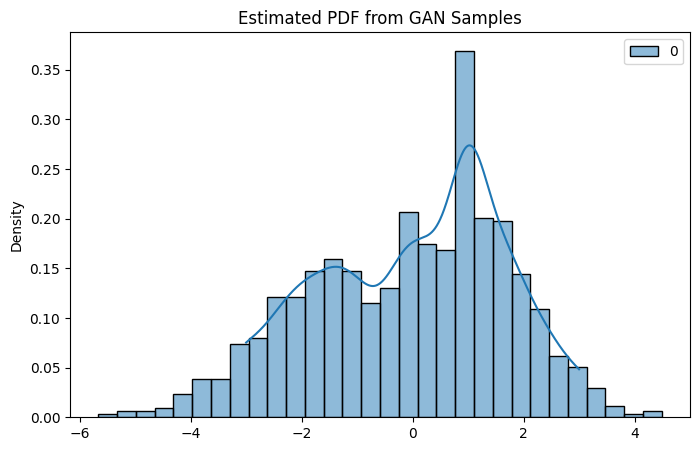

In [5]:
!pip install torch torchvision pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KernelDensity

from google.colab import files
uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)), encoding='latin1')

df.columns = df.columns.str.strip().str.lower()

x = df['no2'].dropna().values
x = x.reshape(-1, 1)

x = (x - x.mean()) / x.std()

r = 102303431
a = 2.0
b = 0.6

z = x + a * np.sin(b * x)

z = torch.tensor(z, dtype=torch.float32)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

G = Generator()
D = Discriminator()

criterion = nn.BCELoss()
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.001)
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.001)

epochs = 300

for epoch in range(epochs):
    real_data = z[torch.randint(0, len(z), (64,))]
    real_labels = torch.ones((64,1))

    noise = torch.randn((64,1))
    fake_data = G(noise)
    fake_labels = torch.zeros((64,1))

    d_optimizer.zero_grad()
    real_loss = criterion(D(real_data), real_labels)
    fake_loss = criterion(D(fake_data.detach()), fake_labels)
    d_loss = real_loss + fake_loss
    d_loss.backward()
    d_optimizer.step()

    g_optimizer.zero_grad()
    noise = torch.randn((64,1))
    fake_data = G(noise)
    g_loss = criterion(D(fake_data), real_labels)
    g_loss.backward()
    g_optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

with torch.no_grad():
    gen_samples = G(torch.randn(1000,1)).numpy()

kde = KernelDensity(kernel='gaussian', bandwidth=0.3)
kde.fit(gen_samples)

x_plot = np.linspace(-3, 3, 1000).reshape(-1,1)
log_dens = kde.score_samples(x_plot)

plt.figure(figsize=(8,5))

sns.histplot(gen_samples, bins=30, stat='density')
plt.plot(x_plot, np.exp(log_dens))

plt.title("Estimated PDF from GAN Samples")
plt.show()